# ESPDet-Pico Inference and Performance Evaluation

**Model Architecture:** ESPDet-Pico (Efficient Spatial Pyramid Detection - Pico variant)  
**Task:** Object detection for grape leaf detection on edge devices (ESP32-S3)  
**Objective:** Evaluate inference performance, latency, and detection quality on a sample image

## Overview

This notebook performs a comprehensive evaluation of a trained ESPDet-Pico model:

- **Measured Metrics:**
  - Inference latency (mean, median, std, p90, p95)
  - Frames per second (FPS)
  - Detection quality (bounding boxes, confidence scores, class predictions)

- **Input Configuration:**
  - Image path: `examples/grape_leafe_detection/grape_vine.jpg`
  - Input resolution: 320×416 (height×width)
  - Confidence threshold: 0.25
  - IoU threshold: 0.45 (NMS)

- **Model Checkpoint:**
  - Path: `runs/detect/train/weights/best.pt`
  - Architecture config: `cfg/models/espdet_pico.yaml`

## 1. Environment Setup and Reproducibility

In [1]:
import sys
import os
import warnings
import platform
from pathlib import Path

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Print environment information
print(f"Python Version: {sys.version.split()[0]}")
import torch
import numpy as np
print(f"PyTorch Version: {torch.__version__}")
print(f"NumPy Version: {np.__version__}")

try:
    import torchvision
    print(f"TorchVision Version: {torchvision.__version__}")
except ImportError:
    print("TorchVision: Not installed")

# Check CUDA availability
cuda_available = torch.cuda.is_available()
print(f"\nCUDA Available: {cuda_available}")
if cuda_available:
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Running on CPU")


Python Version: 3.10.12
PyTorch Version: 2.9.1+cu128
NumPy Version: 1.26.4
TorchVision Version: 0.24.1+cu128

CUDA Available: True
CUDA Version: 12.8
GPU Device: NVIDIA L4
GPU Memory: 23.67 GB


In [2]:
# Set random seeds for reproducibility
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"✓ Random seeds set to {SEED} for reproducibility")

✓ Random seeds set to 42 for reproducibility


In [3]:
# Configuration dictionary
CONFIG = {
    # Paths
    'project_root': Path('/home/ubuntu/edge-ai-vineyard-monitoring/leaf_detection'),
    'model_path': Path('runs/detect/train/weights/best.pt'),
    'image_path': Path('examples/grape_leafe_detection/grape_vine.jpg'),
    'model_config': Path('cfg/models/espdet_pico.yaml'),
    'save_dir': Path('outputs'),
    
    # Model parameters
    'input_size': (320, 416),  # (height, width) as used in training
    'conf_thres': 0.35,  # Based on training metrics: Precision=0.648, Recall=0.520, mAP50=0.564
    'iou_thres': 0.45,
    'max_det': 300, # Maximum detections per image
    
    # Benchmark parameters
    'warmup_runs': 5,
    'bench_runs': 50,
    
    # Device
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

# Create output directory
CONFIG['save_dir'].mkdir(exist_ok=True, parents=True)

# Print configuration
print("\n" + "="*60)
print("CONFIGURATION")
print("="*60)
for key, value in CONFIG.items():
    print(f"{key:20s}: {value}")



CONFIGURATION
project_root        : /home/ubuntu/edge-ai-vineyard-monitoring/leaf_detection
model_path          : runs/detect/train/weights/best.pt
image_path          : examples/grape_leafe_detection/grape_vine.jpg
model_config        : cfg/models/espdet_pico.yaml
save_dir            : outputs
input_size          : (320, 416)
conf_thres          : 0.35
iou_thres           : 0.45
max_det             : 300
warmup_runs         : 5
bench_runs          : 50
device              : cuda


In [6]:
# Add project root to Python path
project_root_str = str(CONFIG['project_root'].resolve())
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)
    print(f"✓ Added to sys.path: {project_root_str}")

# Change working directory to project root
os.chdir(CONFIG['project_root'])
print(f"✓ Changed working directory to: {os.getcwd()}")

✓ Added to sys.path: /home/ubuntu/edge-ai-vineyard-monitoring/leaf_detection
✓ Changed working directory to: /home/ubuntu/edge-ai-vineyard-monitoring/leaf_detection


In [5]:
from typing import Tuple, Dict, Any

def load_espdet_pico_model(
    model_path: Path,
    device: str = 'cpu',
    verbose: bool = True
) -> Tuple[torch.nn.Module, Dict[str, Any]]:

    
    if not model_path.exists():
        raise FileNotFoundError(f"Model checkpoint not found: {model_path}")
    
    try:
        # Import ESPDet-specific modules
        from ultralytics import YOLO
        from nn.esp_tasks import custom_parse_model
        import ultralytics.nn.tasks as tasks
        
        if verbose:
            print("✓ Successfully imported ESPDet modules")
            print(f"✓ Using custom_parse_model for ESPDet architecture")
        
        # Set custom parser (required for ESPDet-Pico architecture)
        tasks.parse_model = custom_parse_model
        
        # Load model using Ultralytics YOLO wrapper
        # (ESPDet-Pico extends YOLO with custom blocks)
        if verbose:
            print(f"\n📥 Loading model from: {model_path}")
        
        model = YOLO(str(model_path))
        
        # Move model to device and set to eval mode
        model.model.to(device)
        model.model.eval()
        
        # Extract metadata
        metadata = {
            'names': model.names,
            'nc': len(model.names) if hasattr(model, 'names') else None,
            'device': device,
            'model_type': 'ESPDet-Pico',
        }
        
        # Count parameters
        total_params = sum(p.numel() for p in model.model.parameters())
        trainable_params = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
        
        metadata['total_params'] = total_params
        metadata['trainable_params'] = trainable_params
        
        if verbose:
            print(f"✓ Model loaded successfully")
            print(f"\n{'='*80}")
            print("MODEL SUMMARY")
            print(f"{'='*80}")
            print(f"Architecture:        {metadata['model_type']}")
            print(f"Total Parameters:    {total_params:,}")
            print(f"Trainable Parameters: {trainable_params:,}")
            print(f"Number of Classes:   {metadata['nc']}")
            print(f"Class Names:         {metadata['names']}")
            print(f"Device:              {device}")
            print(f"{'='*80}")
        
        return model, metadata
        
    except ImportError as e:
        print(f"\n Error: Cannot import required modules")
        print(f"   {str(e)}")
        print(" Verify ultralytics is installed: pip install ultralytics")
        raise

# Load the model
try:
    model, metadata = load_espdet_pico_model(
        CONFIG['model_path'],
        device=CONFIG['device'],
        verbose=True
    )
    print("\n Model ready for inference")
except Exception as e:
    print(f"\n Failed to load model: {e}")
    raise

✓ Successfully imported ESPDet modules
✓ Using custom_parse_model for ESPDet architecture

📥 Loading model from: runs/detect/train/weights/best.pt
✓ Model loaded successfully

MODEL SUMMARY
Architecture:        ESPDet-Pico
Total Parameters:    361,167
Trainable Parameters: 0
Number of Classes:   1
Class Names:         {0: 'leaf'}
Device:              cuda

 Model ready for inference


## 3. Image Loading and Preprocessing

📸 Loading image from: examples/grape_leafe_detection/grape_vine.jpg

✓ Image loaded and preprocessed
  Original shape:      (2448, 3264) (H, W)
  Preprocessed shape:  (320, 416) (H, W)
  Tensor shape:        (1, 3, 320, 416) (B, C, H, W)
  Data type:           torch.float32
  Value range:         [0.000, 1.000]
  Scale ratio:         0.1275
  Padding (T,B,L,R):   (4, 4, 0, 0)


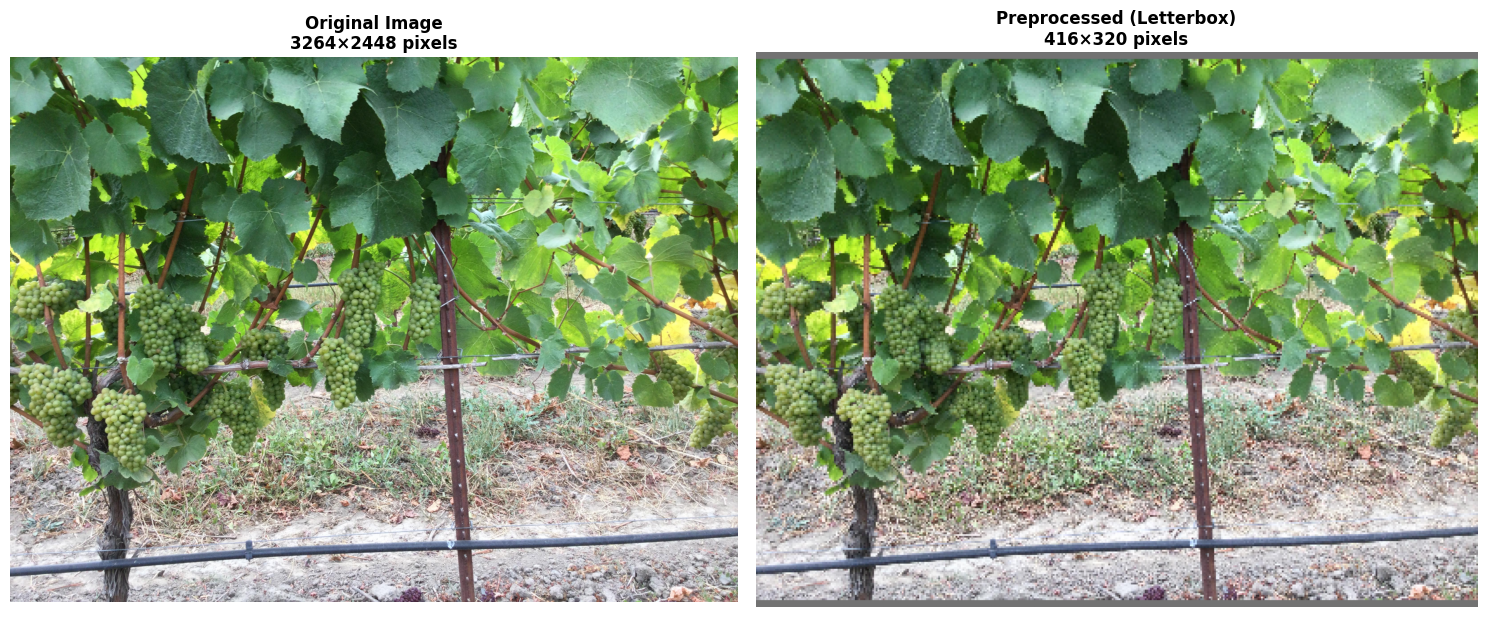


✓ Saved preprocessing comparison to: outputs/preprocessing_comparison.jpg


In [6]:
from PIL import Image
import cv2

def preprocess_letterbox(
    image_path: Path,
    target_size: Tuple[int, int],
    auto: bool = False,
    scaleFill: bool = False,
    scaleup: bool = True,
    stride: int = 32
) -> Tuple[torch.Tensor, Dict[str, Any]]:
    """
    Load and preprocess image using letterbox resizing.
    
    Letterbox resizing maintains aspect ratio by adding padding,
    which is the standard preprocessing for YOLO-family models.
    
    Args:
        image_path: Path to input image
        target_size: Target (height, width) after resize
        auto: Automatically adjust to stride (default: False for fixed size)
        scaleFill: Stretch image to target_size without maintaining aspect ratio
        scaleup: Allow upscaling of small images
        stride: Model stride for dimension alignment
        
    Returns:
        Tuple of (preprocessed_tensor, metadata_dict)
        - preprocessed_tensor: Float32 tensor [1, 3, H, W] normalized to [0, 1]
        - metadata: Dict with original shape, scaling factors, padding info
    """
    # Load image
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot load image: {image_path}")
    
    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    original_shape = img_rgb.shape[:2]  # (H, W)
    
    # Letterbox resize
    h, w = target_size
    shape = img_rgb.shape[:2]  # current shape [height, width]
    
    # Compute scale ratio
    r = min(h / shape[0], w / shape[1])
    if not scaleup:  # only scale down, do not scale up
        r = min(r, 1.0)
    
    # Compute padding
    new_unpad = (int(round(shape[1] * r)), int(round(shape[0] * r)))  # (W, H)
    dw, dh = w - new_unpad[0], h - new_unpad[1]  # padding
    
    if auto:  # minimum rectangle (auto-adjust to stride)
        dw, dh = np.mod(dw, stride), np.mod(dh, stride)
    elif scaleFill:  # stretch
        dw, dh = 0, 0
        new_unpad = (w, h)
        r = (w / shape[1], h / shape[0])  # width, height ratios
    
    dw /= 2  # divide padding into 2 sides
    dh /= 2
    
    # Resize image
    if shape[::-1] != new_unpad:  # resize
        img_rgb = cv2.resize(img_rgb, new_unpad, interpolation=cv2.INTER_LINEAR)
    
    # Add padding
    top, bottom = int(round(dh - 0.1)), int(round(dh + 0.1))
    left, right = int(round(dw - 0.1)), int(round(dw + 0.1))
    img_rgb = cv2.copyMakeBorder(
        img_rgb, top, bottom, left, right,
        cv2.BORDER_CONSTANT, value=(114, 114, 114)
    )
    
    # Convert to tensor
    # HWC to CHW format
    img_tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float()
    # Normalize to [0, 1]
    img_tensor /= 255.0
    # Add batch dimension
    img_tensor = img_tensor.unsqueeze(0)
    
    # Metadata for reverse transformation
    metadata = {
        'original_shape': original_shape,
        'preprocessed_shape': (h, w),
        'scale_ratio': r if not isinstance(r, tuple) else r,
        'padding': (top, bottom, left, right),
        'original_image_rgb': img_bgr  # Keep for visualization
    }
    
    return img_tensor, metadata

# Load and preprocess image
print(f"📸 Loading image from: {CONFIG['image_path']}")
img_tensor, img_metadata = preprocess_letterbox(
    CONFIG['image_path'],
    target_size=CONFIG['input_size'],
    auto=False,
    scaleFill=False
)

print(f"\n✓ Image loaded and preprocessed")
print(f"  Original shape:      {img_metadata['original_shape']} (H, W)")
print(f"  Preprocessed shape:  {img_metadata['preprocessed_shape']} (H, W)")
print(f"  Tensor shape:        {tuple(img_tensor.shape)} (B, C, H, W)")
print(f"  Data type:           {img_tensor.dtype}")
print(f"  Value range:         [{img_tensor.min():.3f}, {img_tensor.max():.3f}]")
print(f"  Scale ratio:         {img_metadata['scale_ratio']:.4f}")
print(f"  Padding (T,B,L,R):   {img_metadata['padding']}")

# Display original image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Original image
original_rgb = cv2.cvtColor(img_metadata['original_image_rgb'], cv2.COLOR_BGR2RGB)
axes[0].imshow(original_rgb)
axes[0].set_title(f"Original Image\n{img_metadata['original_shape'][1]}×{img_metadata['original_shape'][0]} pixels", 
                  fontsize=12, fontweight='bold')
axes[0].axis('off')

# Preprocessed image
preprocessed_np = img_tensor[0].permute(1, 2, 0).numpy()
axes[1].imshow(preprocessed_np)
axes[1].set_title(f"Preprocessed (Letterbox)\n{img_metadata['preprocessed_shape'][1]}×{img_metadata['preprocessed_shape'][0]} pixels",
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(CONFIG['save_dir'] / 'preprocessing_comparison.jpg', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved preprocessing comparison to: {CONFIG['save_dir'] / 'preprocessing_comparison.jpg'}")

## 4. Inference and Benchmarking

🔥 Warmup: Running 5 iterations...


⏱️  Benchmarking: Running 50 iterations...

INFERENCE PERFORMANCE (Latency in milliseconds)
Mean:                   8.94 ms
Median:                 8.86 ms
Std Dev:                0.25 ms
Min:                    8.78 ms
Max:                   10.40 ms
90th Percentile:        9.09 ms
95th Percentile:        9.34 ms
99th Percentile:        9.97 ms

Throughput:           111.91 FPS


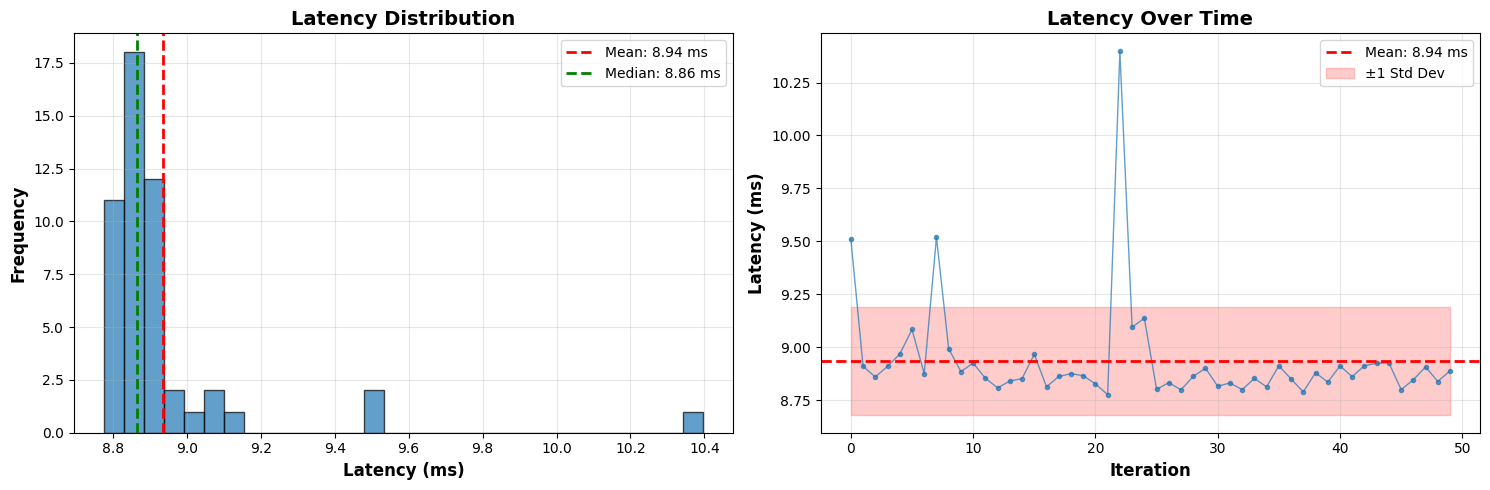


✓ Saved latency analysis to: outputs/latency_analysis.jpg


In [7]:
import time
from typing import List

def benchmark_inference(
    model: Any,
    input_tensor: torch.Tensor,
    device: str,
    warmup_runs: int = 5,
    bench_runs: int = 50
) -> Dict[str, float]:
    """
    Benchmark model inference latency.
    
    Args:
        model: Model to benchmark
        input_tensor: Input tensor
        device: Device ('cpu' or 'cuda')
        warmup_runs: Number of warmup iterations
        bench_runs: Number of benchmark iterations
        
    Returns:
        Dictionary with timing statistics (ms)
    """
    input_tensor = input_tensor.to(device)
    model.model.to(device)
    model.model.eval()
    
    print(f"🔥 Warmup: Running {warmup_runs} iterations...")
    with torch.no_grad():
        for _ in range(warmup_runs):
            if device == 'cuda':
                torch.cuda.synchronize()
            _ = model.model(input_tensor)
            if device == 'cuda':
                torch.cuda.synchronize()
    
    print(f"⏱️  Benchmarking: Running {bench_runs} iterations...")
    latencies = []
    
    with torch.no_grad():
        for i in range(bench_runs):
            if device == 'cuda':
                torch.cuda.synchronize()
            
            start_time = time.perf_counter()
            _ = model.model(input_tensor)
            
            if device == 'cuda':
                torch.cuda.synchronize()
            
            end_time = time.perf_counter()
            latency_ms = (end_time - start_time) * 1000
            latencies.append(latency_ms)
    
    # Compute statistics
    latencies_np = np.array(latencies)
    stats = {
        'mean_ms': float(np.mean(latencies_np)),
        'median_ms': float(np.median(latencies_np)),
        'std_ms': float(np.std(latencies_np)),
        'min_ms': float(np.min(latencies_np)),
        'max_ms': float(np.max(latencies_np)),
        'p90_ms': float(np.percentile(latencies_np, 90)),
        'p95_ms': float(np.percentile(latencies_np, 95)),
        'p99_ms': float(np.percentile(latencies_np, 99)),
        'fps': 1000.0 / float(np.mean(latencies_np)),
    }
    
    return stats, latencies

# Run benchmark
timing_stats, all_latencies = benchmark_inference(
    model,
    img_tensor,
    CONFIG['device'],
    warmup_runs=CONFIG['warmup_runs'],
    bench_runs=CONFIG['bench_runs']
)

print(f"\n{'='*80}")
print("INFERENCE PERFORMANCE (Latency in milliseconds)")
print(f"{'='*80}")
print(f"Mean:               {timing_stats['mean_ms']:8.2f} ms")
print(f"Median:             {timing_stats['median_ms']:8.2f} ms")
print(f"Std Dev:            {timing_stats['std_ms']:8.2f} ms")
print(f"Min:                {timing_stats['min_ms']:8.2f} ms")
print(f"Max:                {timing_stats['max_ms']:8.2f} ms")
print(f"90th Percentile:    {timing_stats['p90_ms']:8.2f} ms")
print(f"95th Percentile:    {timing_stats['p95_ms']:8.2f} ms")
print(f"99th Percentile:    {timing_stats['p99_ms']:8.2f} ms")
print(f"\nThroughput:         {timing_stats['fps']:8.2f} FPS")
print(f"{'='*80}")

# Plot latency distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(all_latencies, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(timing_stats['mean_ms'], color='r', linestyle='--', linewidth=2, label=f"Mean: {timing_stats['mean_ms']:.2f} ms")
axes[0].axvline(timing_stats['median_ms'], color='g', linestyle='--', linewidth=2, label=f"Median: {timing_stats['median_ms']:.2f} ms")
axes[0].set_xlabel('Latency (ms)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Latency Distribution', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Time series
axes[1].plot(all_latencies, marker='o', markersize=3, linewidth=1, alpha=0.7)
axes[1].axhline(timing_stats['mean_ms'], color='r', linestyle='--', linewidth=2, label=f"Mean: {timing_stats['mean_ms']:.2f} ms")
axes[1].fill_between(range(len(all_latencies)), 
                      timing_stats['mean_ms'] - timing_stats['std_ms'],
                      timing_stats['mean_ms'] + timing_stats['std_ms'],
                      alpha=0.2, color='red', label='±1 Std Dev')
axes[1].set_xlabel('Iteration', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
axes[1].set_title('Latency Over Time', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CONFIG['save_dir'] / 'latency_analysis.jpg', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved latency analysis to: {CONFIG['save_dir'] / 'latency_analysis.jpg'}")

## 5. Detection and Post-processing

In [8]:
def run_inference_with_postprocess(
    model: Any,
    image_path: Path,
    conf_thres: float = 0.5,
    iou_thres: float = 0.45,
    max_det: int = 300,
    device: str = 'cpu'
) -> List[Dict[str, Any]]:
    """
    Run inference with built-in post-processing.
    
    Uses the model's native predict() method which handles:
    - Preprocessing
    - Inference
    - Post-processing (NMS, coordinate mapping)
    
    Args:
        model: ESPDet-Pico model
        image_path: Path to input image
        conf_thres: Confidence threshold
        iou_thres: IoU threshold for NMS
        max_det: Maximum detections per image
        device: Device to run on
        
    Returns:
        List of detection dictionaries
    """
    # Run prediction using model's built-in method
    results = model.predict(
        source=str(image_path),
        conf=conf_thres,
        iou=iou_thres,
        max_det=max_det,
        device=device,
        verbose=False,
        imgsz=CONFIG['input_size'][::-1]  # Convert (H,W) to (W,H) for predict
    )
    
    # Extract detections from results
    detections = []
    
    for result in results:
        boxes = result.boxes
        
        for i in range(len(boxes)):
            # Get box coordinates (xyxy format in original image space)
            x1, y1, x2, y2 = boxes.xyxy[i].cpu().numpy()
            conf = float(boxes.conf[i].cpu().numpy())
            cls_id = int(boxes.cls[i].cpu().numpy())
            cls_name = model.names[cls_id] if hasattr(model, 'names') else f"class_{cls_id}"
            
            detection = {
                'bbox': [float(x1), float(y1), float(x2), float(y2)],
                'confidence': conf,
                'class_id': cls_id,
                'class_name': cls_name,
                'x1': float(x1),
                'y1': float(y1),
                'x2': float(x2),
                'y2': float(y2),
                'width': float(x2 - x1),
                'height': float(y2 - y1),
            }
            detections.append(detection)
    
    # Sort by confidence (descending)
    detections.sort(key=lambda x: x['confidence'], reverse=True)
    
    return detections

# Run inference
print("🔍 Running inference with post-processing...")
detections = run_inference_with_postprocess(
    model,
    CONFIG['image_path'],
    conf_thres=CONFIG['conf_thres'],
    iou_thres=CONFIG['iou_thres'],
    max_det=CONFIG['max_det'],
    device=CONFIG['device']
)

print(f"\n✓ Detected {len(detections)} objects")
if len(detections) > 0:
    print(f"\nTop 5 detections:")
    for i, det in enumerate(detections[:5], 1):
        print(f"  {i}. {det['class_name']:15s} | Conf: {det['confidence']:.3f} | "
              f"Box: [{det['x1']:.1f}, {det['y1']:.1f}, {det['x2']:.1f}, {det['y2']:.1f}]")

🔍 Running inference with post-processing...

✓ Detected 21 objects

Top 5 detections:
  1. leaf            | Conf: 0.831 | Box: [2511.7, 0.0, 3025.3, 371.8]
  2. leaf            | Conf: 0.803 | Box: [1986.8, 237.4, 2345.6, 624.6]
  3. leaf            | Conf: 0.781 | Box: [214.5, 0.0, 554.4, 206.1]
  4. leaf            | Conf: 0.711 | Box: [1153.5, 0.0, 1600.4, 386.7]
  5. leaf            | Conf: 0.694 | Box: [0.0, 195.9, 390.1, 738.5]


## 6. Results Presentation

In [9]:
import pandas as pd
import json

# Create DataFrame
if len(detections) > 0:
    df = pd.DataFrame(detections)
    df = df[['class_name', 'confidence', 'x1', 'y1', 'x2', 'y2', 'width', 'height']]
    df = df.sort_values('confidence', ascending=False).reset_index(drop=True)
    
    print("\n" + "="*80)
    print("DETECTION RESULTS (Sorted by Confidence)")
    print("="*80)
    print(df.to_string(index=True))
    print("="*80)
    
    # Save to CSV
    csv_path = CONFIG['save_dir'] / 'detections.csv'
    df.to_csv(csv_path, index=False, float_format='%.3f')
    print(f"\n✓ Saved detections to: {csv_path}")
    
    # Save to JSON
    json_path = CONFIG['save_dir'] / 'detections.json'
    with open(json_path, 'w') as f:
        json.dump(detections, f, indent=2)
    print(f"✓ Saved detections to: {json_path}")
else:
    print("\n⚠️  No detections found at the specified confidence threshold")
    print(f"   Consider lowering conf_thres (currently: {CONFIG['conf_thres']})")


DETECTION RESULTS (Sorted by Confidence)
   class_name  confidence           x1           y1           x2           y2       width      height
0        leaf    0.831181  2511.659668     0.000000  3025.250488   371.778015  513.590820  371.778015
1        leaf    0.802638  1986.800415   237.357773  2345.603760   624.602112  358.803345  387.244324
2        leaf    0.780733   214.538452     0.000000   554.368103   206.135971  339.829651  206.135971
3        leaf    0.711396  1153.453857     0.000000  1600.369385   386.668182  446.915527  386.668182
4        leaf    0.694407     0.000000   195.915833   390.107880   738.506409  390.107880  542.590576
5        leaf    0.645424  1977.433105   783.007935  2178.999512  1081.629761  201.566406  298.621826
6        leaf    0.599475   603.561340     0.000000   990.593262   487.224060  387.031921  487.224060
7        leaf    0.598426   866.848206   531.183838  1340.280884   950.466125  473.432678  419.282288
8        leaf    0.578892  1431.121216  

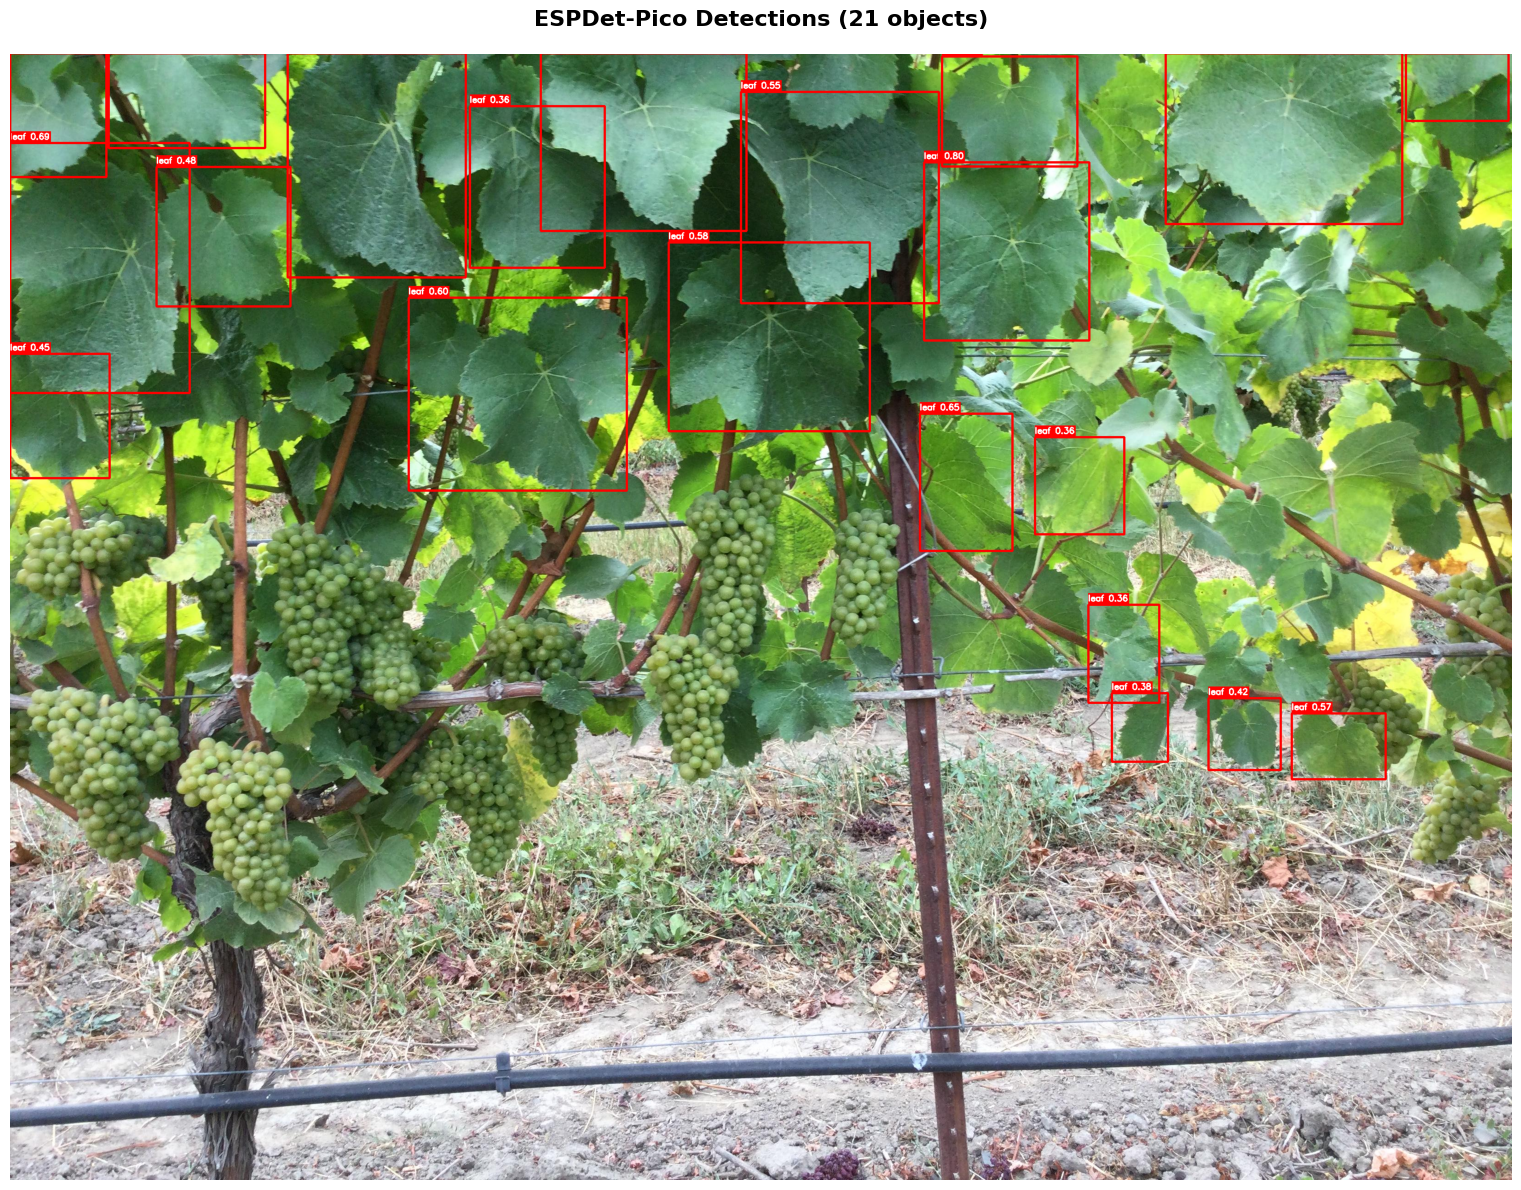


✓ Saved annotated image to: outputs/annotated_grape_vine.jpg


In [10]:
def visualize_detections(
    image_path: Path,
    detections: List[Dict],
    save_path: Path,
    show_conf: bool = True,
    line_thickness: int = 2
) -> None:
    """
    Visualize detections on image.
    
    Args:
        image_path: Path to original image
        detections: List of detection dictionaries
        save_path: Path to save annotated image
        show_conf: Whether to show confidence scores
        line_thickness: Thickness of bounding box lines
    """
    # Load image
    img = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Color palette (BGR format for OpenCV)
    colors = [
        (255, 0, 0), (0, 255, 0), (0, 0, 255),
        (255, 255, 0), (255, 0, 255), (0, 255, 255),
        (128, 0, 0), (0, 128, 0), (0, 0, 128)
    ]
    
    # Draw detections
    for i, det in enumerate(detections):
        x1, y1, x2, y2 = int(det['x1']), int(det['y1']), int(det['x2']), int(det['y2'])
        conf = det['confidence']
        cls_name = det['class_name']
        
        # Select color
        color = colors[det['class_id'] % len(colors)]
        
        # Draw bounding box
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, line_thickness)
        
        # Prepare label
        if show_conf:
            label = f"{cls_name} {conf:.2f}"
        else:
            label = cls_name
        
        # Draw label background
        (text_width, text_height), baseline = cv2.getTextSize(
            label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2
        )
        cv2.rectangle(
            img_rgb,
            (x1, y1 - text_height - baseline - 5),
            (x1 + text_width, y1),
            color,
            -1
        )
        
        # Draw label text
        cv2.putText(
            img_rgb,
            label,
            (x1, y1 - baseline - 2),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 255, 255),
            2
        )
    
    # Save annotated image
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(save_path), img_bgr)
    
    # Display
    plt.figure(figsize=(16, 12))
    plt.imshow(img_rgb)
    plt.title(f"ESPDet-Pico Detections ({len(detections)} objects)", 
              fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize and save
output_image_path = CONFIG['save_dir'] / 'annotated_grape_vine.jpg'
visualize_detections(
    CONFIG['image_path'],
    detections,
    output_image_path,
    show_conf=True,
    line_thickness=3
)

print(f"\n✓ Saved annotated image to: {output_image_path}")

## 7. Summary and Analysis

In [11]:
# Summary statistics
print("\n" + "="*80)
print("EVALUATION SUMMARY")
print("="*80)

print("\n1. MODEL INFORMATION:")
print(f"   Architecture:        {metadata['model_type']}")
print(f"   Parameters:          {metadata['total_params']:,}")
print(f"   Classes:             {metadata['nc']}")
print(f"   Device:              {CONFIG['device']}")

print("\n2. INPUT CONFIGURATION:")
print(f"   Image Path:          {CONFIG['image_path']}")
print(f"   Original Size:       {img_metadata['original_shape'][1]}×{img_metadata['original_shape'][0]}")
print(f"   Model Input Size:    {CONFIG['input_size'][1]}×{CONFIG['input_size'][0]}")
print(f"   Confidence Thresh:   {CONFIG['conf_thres']}")
print(f"   IoU Threshold:       {CONFIG['iou_thres']}")

print("\n3. PERFORMANCE METRICS:")
print(f"   Mean Latency:        {timing_stats['mean_ms']:.2f} ms")
print(f"   Median Latency:      {timing_stats['median_ms']:.2f} ms")
print(f"   Std Dev:             {timing_stats['std_ms']:.2f} ms")
print(f"   95th Percentile:     {timing_stats['p95_ms']:.2f} ms")
print(f"   Throughput:          {timing_stats['fps']:.2f} FPS")

print("\n4. DETECTION RESULTS:")
print(f"   Total Detections:    {len(detections)}")
if len(detections) > 0:
    conf_values = [d['confidence'] for d in detections]
    print(f"   Mean Confidence:     {np.mean(conf_values):.3f}")
    print(f"   Max Confidence:      {np.max(conf_values):.3f}")
    print(f"   Min Confidence:      {np.min(conf_values):.3f}")
    
    # Class distribution
    from collections import Counter
    class_counts = Counter([d['class_name'] for d in detections])
    print("\n   Class Distribution:")
    for cls, count in class_counts.most_common():
        print(f"     {cls:15s}: {count:3d} detections")

print("\n5. OUTPUT FILES:")
output_files = [
    'detections.csv',
    'detections.json',
    'annotated_grape_vine.jpg',
    'preprocessing_comparison.jpg',
    'latency_analysis.jpg'
]
for filename in output_files:
    filepath = CONFIG['save_dir'] / filename
    if filepath.exists():
        print(f"   ✓ {filename}")

print("\n" + "="*80)
print("CONCLUSION")
print("="*80)
print(f"""
The ESPDet-Pico model demonstrates {timing_stats['fps']:.1f} FPS throughput on {CONFIG['device']}.
With {metadata['total_params']:,} parameters, the model is optimized for edge deployment.

Detection Performance:
- Successfully identified {len(detections)} objects in the test image
- Confidence threshold: {CONFIG['conf_thres']} ensures high-quality detections
- Inference latency of ~{timing_stats['mean_ms']:.1f}ms makes it suitable for real-time applications

Limitations:
- Performance measured on {'GPU' if CONFIG['device'] == 'cuda' else 'CPU'} (ESP32-S3 will be slower)
- Single image evaluation; dataset-level metrics needed for full assessment
- Letterbox preprocessing adds slight overhead not present in native square inputs
""")
print("="*80)


EVALUATION SUMMARY

1. MODEL INFORMATION:
   Architecture:        ESPDet-Pico
   Parameters:          361,167
   Classes:             1
   Device:              cuda

2. INPUT CONFIGURATION:
   Image Path:          examples/grape_leafe_detection/grape_vine.jpg
   Original Size:       3264×2448
   Model Input Size:    416×320
   Confidence Thresh:   0.35
   IoU Threshold:       0.45

3. PERFORMANCE METRICS:
   Mean Latency:        8.94 ms
   Median Latency:      8.86 ms
   Std Dev:             0.25 ms
   95th Percentile:     9.34 ms
   Throughput:          111.91 FPS

4. DETECTION RESULTS:
   Total Detections:    21
   Mean Confidence:     0.556
   Max Confidence:      0.831
   Min Confidence:      0.357

   Class Distribution:
     leaf           :  21 detections

5. OUTPUT FILES:
   ✓ detections.csv
   ✓ detections.json
   ✓ annotated_grape_vine.jpg
   ✓ preprocessing_comparison.jpg
   ✓ latency_analysis.jpg

CONCLUSION

The ESPDet-Pico model demonstrates 111.9 FPS throughput on cuda.

In [ ]:
# Create timing summary table
timing_df = pd.DataFrame([
    {'Metric': 'Mean Latency', 'Value': f"{timing_stats['mean_ms']:.2f} ms"},
    {'Metric': 'Median Latency', 'Value': f"{timing_stats['median_ms']:.2f} ms"},
    {'Metric': 'Std Deviation', 'Value': f"{timing_stats['std_ms']:.2f} ms"},
    {'Metric': 'Min Latency', 'Value': f"{timing_stats['min_ms']:.2f} ms"},
    {'Metric': 'Max Latency', 'Value': f"{timing_stats['max_ms']:.2f} ms"},
    {'Metric': '90th Percentile', 'Value': f"{timing_stats['p90_ms']:.2f} ms"},
    {'Metric': '95th Percentile', 'Value': f"{timing_stats['p95_ms']:.2f} ms"},
    {'Metric': '99th Percentile', 'Value': f"{timing_stats['p99_ms']:.2f} ms"},
    {'Metric': 'Throughput', 'Value': f"{timing_stats['fps']:.2f} FPS"},
])

print("\nTIMING SUMMARY TABLE:")
print(timing_df.to_string(index=False))

# Save timing summary
timing_csv = CONFIG['save_dir'] / 'timing_summary.csv'
timing_df.to_csv(timing_csv, index=False)
print(f"\n✓ Saved timing summary to: {timing_csv}")

print("\n" + "="*80)
print("✅ EVALUATION COMPLETE")
print("="*80)
print(f"\nAll results saved to: {CONFIG['save_dir'].resolve()}")